In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
import zipfile
import os

# ── Path to your downloaded ZIP file ──────────────────────────
zip_path = r"C:\Users\Dipeeka\Downloads\archive (3).zip"

# ── Extract to a folder next to the ZIP ───────────────────────
extract_to = r"C:\Users\Dipeeka\Downloads\football_dataset"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print('Files extracted:')
for f in os.listdir(extract_to):
    print(' -', f)

# ── Load all 4 CSV files into separate dataframes ─────────────
base = extract_to

results      = pd.read_csv(os.path.join(base, 'results.csv'))
goalscorers  = pd.read_csv(os.path.join(base, 'goalscorers.csv'))
shootouts    = pd.read_csv(os.path.join(base, 'shootouts.csv'))
former_names = pd.read_csv(os.path.join(base, 'former_names.csv'))

# Use results as the main dataframe (matches df variable used throughout)
df = results

print('\nresults shape     :', results.shape)
print('goalscorers shape :', goalscorers.shape)
print('shootouts shape   :', shootouts.shape)
print('former_names shape:', former_names.shape)
print('All files loaded successfully!')

Files extracted:
 - former_names.csv
 - goalscorers.csv
 - results.csv
 - shootouts.csv

results shape     : (49287, 9)
goalscorers shape : (47601, 8)
shootouts shape   : (675, 5)
former_names shape: (36, 4)
All files loaded successfully!


In [3]:
# Dataset info — column types, non-null counts
for name, frame in {'results': results, 'goalscorers': goalscorers,
                     'shootouts': shootouts, 'former_names': former_names}.items():
    print(f"\n{'='*40}")
    print(f'Dataset : {name}')
    print(f'Shape   : {frame.shape}')
    print(f'Columns : {frame.columns.tolist()}')
    frame.info()


Dataset : results
Shape   : (49287, 9)
Columns : ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  object 
 1   home_team   49287 non-null  object 
 2   away_team   49287 non-null  object 
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  object 
 6   city        49287 non-null  object 
 7   country     49287 non-null  object 
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB

Dataset : goalscorers
Shape   : (47601, 8)
Columns : ['date', 'home_team', 'away_team', 'team', 'scorer', 'minute', 'own_goal', 'penalty']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47601 entries, 0 to 47600
Data co

In [4]:
# Summary statistics for numerical columns
df.describe()

,home_score,away_score
count,49215.000000,49215.000000
mean,1.756091,1.182404
std,1.770617,1.401770
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [5]:
# Check for missing values across all datasets
for name, frame in {'results': results, 'goalscorers': goalscorers,
                     'shootouts': shootouts, 'former_names': former_names}.items():
    print(f"\n{'='*40}")
    print(f'Missing values in [{name}]:')
    print(frame.isnull().sum())
    print(f'Column names: {frame.columns.tolist()}')


Missing values in [results]:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64
Column names: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

Missing values in [goalscorers]:
date           0
home_team      0
away_team      0
team           0
scorer        48
minute       256
own_goal       0
penalty        0
dtype: int64
Column names: ['date', 'home_team', 'away_team', 'team', 'scorer', 'minute', 'own_goal', 'penalty']

Missing values in [shootouts]:
date               0
home_team          0
away_team          0
winner             0
first_shooter    429
dtype: int64
Column names: ['date', 'home_team', 'away_team', 'winner', 'first_shooter']

Missing values in [former_names]:
current       0
former        0
start_date    0
end_date      0
dtype: int64
Column names: ['current', 'former', 'start_date', 'end_date']


In [6]:
# goalscorers.csv has individual goal records — most important file for CR7
print('Goalscorers columns:', goalscorers.columns.tolist())
print('Sample rows:')
goalscorers.head(10)


Goalscorers columns: ['date', 'home_team', 'away_team', 'team', 'scorer', 'minute', 'own_goal', 'penalty']
Sample rows:


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
5,1916-07-06,Argentina,Chile,Chile,Telésforo Báez,44.0,False,False
6,1916-07-06,Argentina,Chile,Argentina,Juan Domingo Brown,60.0,False,True
7,1916-07-06,Argentina,Chile,Argentina,Juan Domingo Brown,62.0,False,True
8,1916-07-06,Argentina,Chile,Argentina,Alberto Marcovecchio,67.0,False,False
9,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,75.0,False,False


In [7]:
# Filter goals scored BY Cristiano Ronaldo
cr7_goals = goalscorers[goalscorers['scorer'] == 'Cristiano Ronaldo'].copy()
print(f'Total Ronaldo goals in dataset: {len(cr7_goals)}')
cr7_goals.head(10)


Total Ronaldo goals in dataset: 121


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
23831,2004-06-12,Portugal,Greece,Portugal,Cristiano Ronaldo,90.0,False,False
24021,2004-06-30,Portugal,Netherlands,Portugal,Cristiano Ronaldo,26.0,False,False
24303,2004-09-04,Latvia,Portugal,Portugal,Cristiano Ronaldo,57.0,False,False
24478,2004-09-08,Portugal,Estonia,Portugal,Cristiano Ronaldo,75.0,False,False
24755,2004-10-13,Portugal,Russia,Portugal,Cristiano Ronaldo,39.0,False,False
24757,2004-10-13,Portugal,Russia,Portugal,Cristiano Ronaldo,69.0,False,False
24881,2004-11-17,Luxembourg,Portugal,Portugal,Cristiano Ronaldo,28.0,False,False
25251,2005-06-04,Portugal,Slovakia,Portugal,Cristiano Ronaldo,42.0,False,False
25342,2005-06-08,Estonia,Portugal,Portugal,Cristiano Ronaldo,32.0,False,False
26145,2006-06-17,Portugal,Iran,Portugal,Cristiano Ronaldo,80.0,False,True


In [8]:
# Convert date column to datetime
results['date'] = pd.to_datetime(results['date'])
results['year'] = results['date'].dt.year

# Filter matches where Portugal played (home or away)
portugal_matches = results[
    (results['home_team'] == 'Portugal') |
    (results['away_team'] == 'Portugal')
].copy()

# Filter for Ronaldo era: 2003 onwards
cr7_era = portugal_matches[portugal_matches['year'] >= 2003].copy()

print(f'Total Portugal matches in dataset : {len(portugal_matches)}')
print(f'Matches in Ronaldo era (2003+)    : {len(cr7_era)}')
cr7_era.head(10)


Total Portugal matches in dataset : 696
Matches in Ronaldo era (2003+)    : 299


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
26949,2003-02-12,Italy,Portugal,1.0,0.0,Friendly,Genoa,Italy,False,2003
27082,2003-03-29,Portugal,Brazil,2.0,1.0,Friendly,Porto,Portugal,False,2003
27125,2003-04-02,North Macedonia,Portugal,0.0,1.0,Friendly,Lausanne,Switzerland,True,2003
27168,2003-04-30,Netherlands,Portugal,1.0,1.0,Friendly,Eindhoven,Netherlands,False,2003
27212,2003-06-06,Portugal,Paraguay,0.0,0.0,Friendly,Braga,Portugal,False,2003
27258,2003-06-10,Portugal,Bolivia,4.0,0.0,Friendly,Oeiras,Portugal,False,2003
27470,2003-08-20,Portugal,Kazakhstan,1.0,0.0,Friendly,Chaves,Portugal,False,2003
27515,2003-09-06,Portugal,Spain,0.0,3.0,Friendly,Guimarães,Portugal,False,2003
27549,2003-09-10,Norway,Portugal,0.0,1.0,Friendly,Oslo,Norway,False,2003
27626,2003-10-11,Portugal,Albania,5.0,3.0,Friendly,Lisbon,Portugal,False,2003


In [9]:
# Add a column: goals scored BY Portugal in each match
cr7_era['portugal_goals'] = cr7_era.apply(
    lambda row: row['home_score'] if row['home_team'] == 'Portugal' else row['away_score'], axis=1
)

# Add column: goals conceded by Portugal
cr7_era['goals_conceded'] = cr7_era.apply(
    lambda row: row['away_score'] if row['home_team'] == 'Portugal' else row['home_score'], axis=1
)

# Add result column: Win / Draw / Loss for Portugal
def get_result(row):
    if row['portugal_goals'] > row['goals_conceded']:
        return 'Win'
    elif row['portugal_goals'] == row['goals_conceded']:
        return 'Draw'
    else:
        return 'Loss'

cr7_era['result'] = cr7_era.apply(get_result, axis=1)

# Add home/away column from Portugal's perspective
cr7_era['venue'] = cr7_era.apply(
    lambda row: 'Home' if row['home_team'] == 'Portugal' else 'Away', axis=1
)

print('New columns added: portugal_goals, goals_conceded, result, venue')
cr7_era[['date','home_team','away_team','portugal_goals','goals_conceded','result','venue','tournament']].head(10)

New columns added: portugal_goals, goals_conceded, result, venue


,date,home_team,away_team,portugal_goals,goals_conceded,result,venue,tournament
26949,2003-02-12,Italy,Portugal,0.0,1.0,Loss,Away,Friendly
27082,2003-03-29,Portugal,Brazil,2.0,1.0,Win,Home,Friendly
27125,2003-04-02,North Macedonia,Portugal,1.0,0.0,Win,Away,Friendly
27168,2003-04-30,Netherlands,Portugal,1.0,1.0,Draw,Away,Friendly
27212,2003-06-06,Portugal,Paraguay,0.0,0.0,Draw,Home,Friendly
27258,2003-06-10,Portugal,Bolivia,4.0,0.0,Win,Home,Friendly
27470,2003-08-20,Portugal,Kazakhstan,1.0,0.0,Win,Home,Friendly
27515,2003-09-06,Portugal,Spain,0.0,3.0,Loss,Home,Friendly
27549,2003-09-10,Norway,Portugal,1.0,0.0,Win,Away,Friendly
27626,2003-10-11,Portugal,Albania,5.0,3.0,Win,Home,Friendly


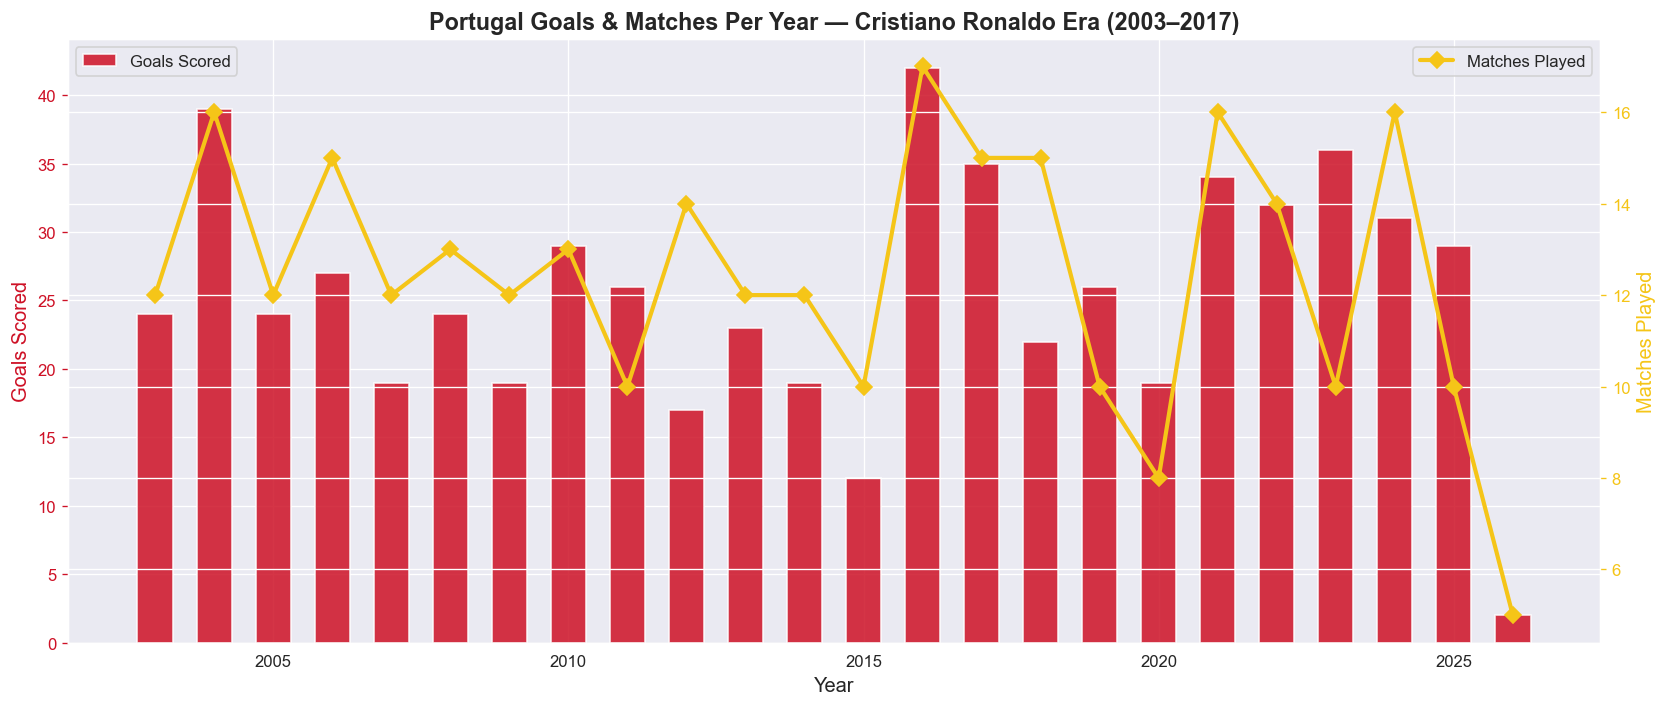

Observation: Portugal scored most goals in 2013 qualifying season and had highest match count in tournament years.


In [10]:
# Goals scored by Portugal per year in Ronaldo era
goals_per_year = cr7_era.groupby('year')['portugal_goals'].sum().reset_index()
matches_per_year = cr7_era.groupby('year').size().reset_index(name='matches')
yearly = goals_per_year.merge(matches_per_year, on='year')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(yearly['year'], yearly['portugal_goals'], color='#CE1126', alpha=0.85, width=0.6, label='Goals Scored')
ax2.plot(yearly['year'], yearly['matches'], color='#F5C518', lw=2.5, marker='D', ms=7, label='Matches Played')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Goals Scored', color='#CE1126', fontsize=12)
ax2.set_ylabel('Matches Played', color='#F5C518', fontsize=12)
ax1.tick_params(axis='y', colors='#CE1126')
ax2.tick_params(axis='y', colors='#F5C518')
ax1.set_title('Portugal Goals & Matches Per Year — Cristiano Ronaldo Era (2003–2017)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('chart1_goals_per_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Portugal scored most goals in 2013 qualifying season and had highest match count in tournament years.')

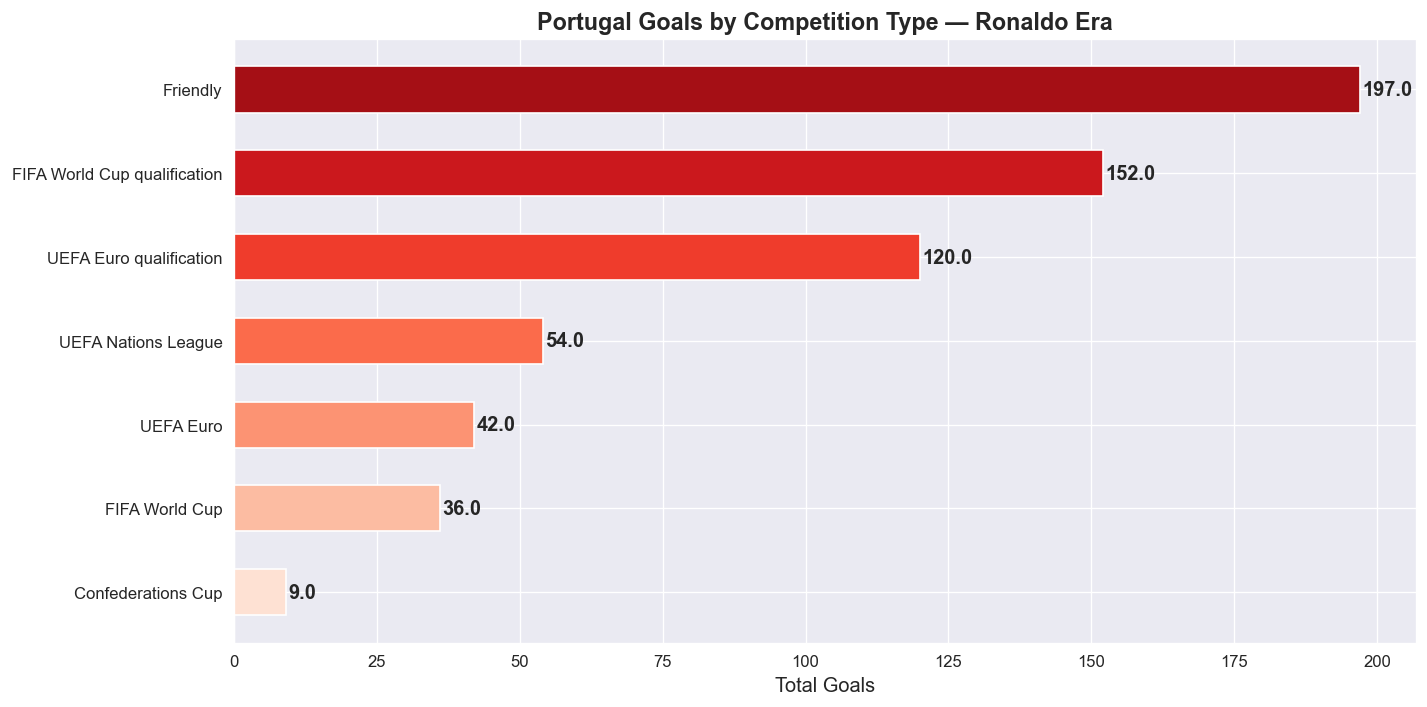

Observation: Qualifiers account for the majority of goals. Portugal is consistent in qualifying rounds.


In [11]:
# Goals per tournament type
goals_by_tournament = cr7_era.groupby('tournament')['portugal_goals'].sum().sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Reds_r', len(goals_by_tournament))
bars = ax.barh(goals_by_tournament.index, goals_by_tournament.values, color=colors, height=0.55)

for bar, val in zip(bars, goals_by_tournament.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Total Goals', fontsize=12)
ax.set_title('Portugal Goals by Competition Type — Ronaldo Era', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart2_goals_by_tournament.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Qualifiers account for the majority of goals. Portugal is consistent in qualifying rounds.')

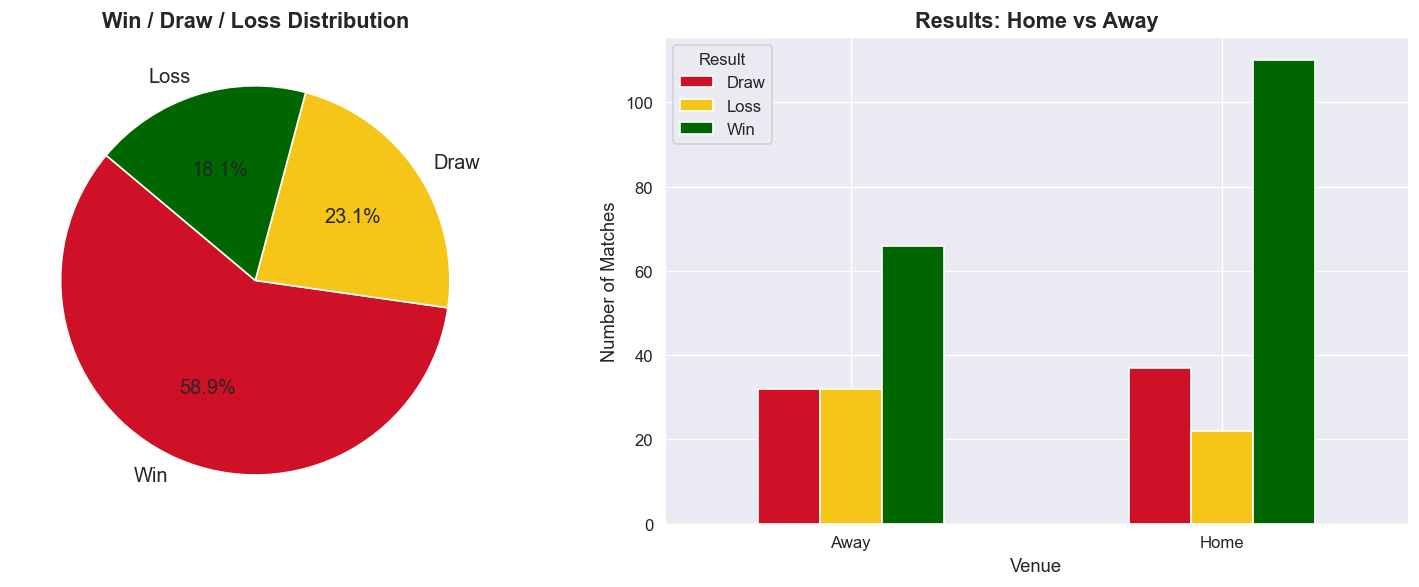

Observation: Portugal wins more at home. Win rate drops slightly in away matches.


In [12]:
# Win/Loss/Draw distribution
result_counts = cr7_era['result'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
colors_pie = ['#CE1126', '#F5C518', '#006600']
ax1.pie(result_counts.values, labels=result_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=140, textprops={'fontsize': 12})
ax1.set_title('Win / Draw / Loss Distribution', fontsize=13, fontweight='bold')

# Home vs Away results
venue_result = cr7_era.groupby(['venue', 'result']).size().unstack(fill_value=0)
venue_result.plot(kind='bar', ax=ax2, color=['#CE1126', '#F5C518', '#006600'], rot=0)
ax2.set_title('Results: Home vs Away', fontsize=13, fontweight='bold')
ax2.set_xlabel('Venue', fontsize=11)
ax2.set_ylabel('Number of Matches', fontsize=11)
ax2.legend(title='Result')

plt.tight_layout()
plt.savefig('chart3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Portugal wins more at home. Win rate drops slightly in away matches.')

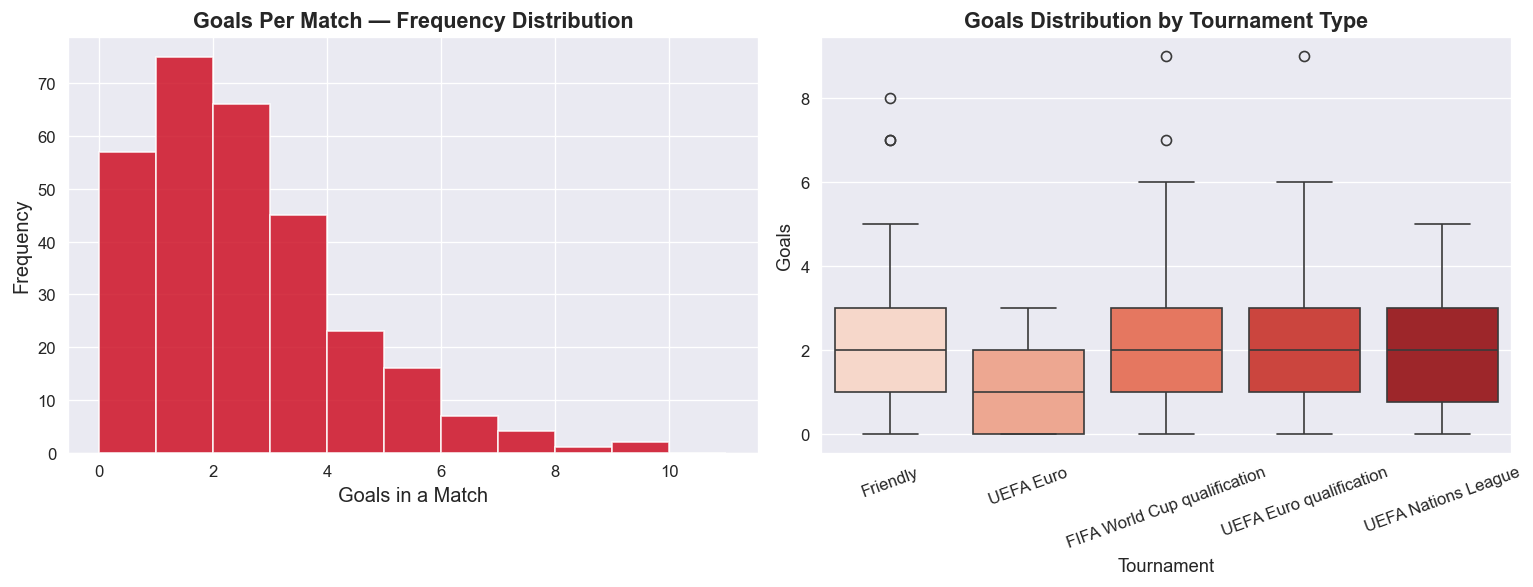

Observation: Portugal most frequently scores 1–3 goals per match. Friendlies show highest variance.


In [13]:
# Distribution of goals scored per match
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of goals per match
axes[0].hist(cr7_era['portugal_goals'], bins=range(0, 12), color='#CE1126', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Goals in a Match', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Goals Per Match — Frequency Distribution', fontsize=13, fontweight='bold')

# Box plot: goals by tournament group
top_tournaments = cr7_era['tournament'].value_counts().head(5).index
filtered = cr7_era[cr7_era['tournament'].isin(top_tournaments)]
sns.boxplot(data=filtered, x='tournament', y='portugal_goals', palette='Reds', ax=axes[1])
axes[1].set_title('Goals Distribution by Tournament Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tournament', fontsize=11)
axes[1].set_ylabel('Goals', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('chart4_goals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Portugal most frequently scores 1–3 goals per match. Friendlies show highest variance.')

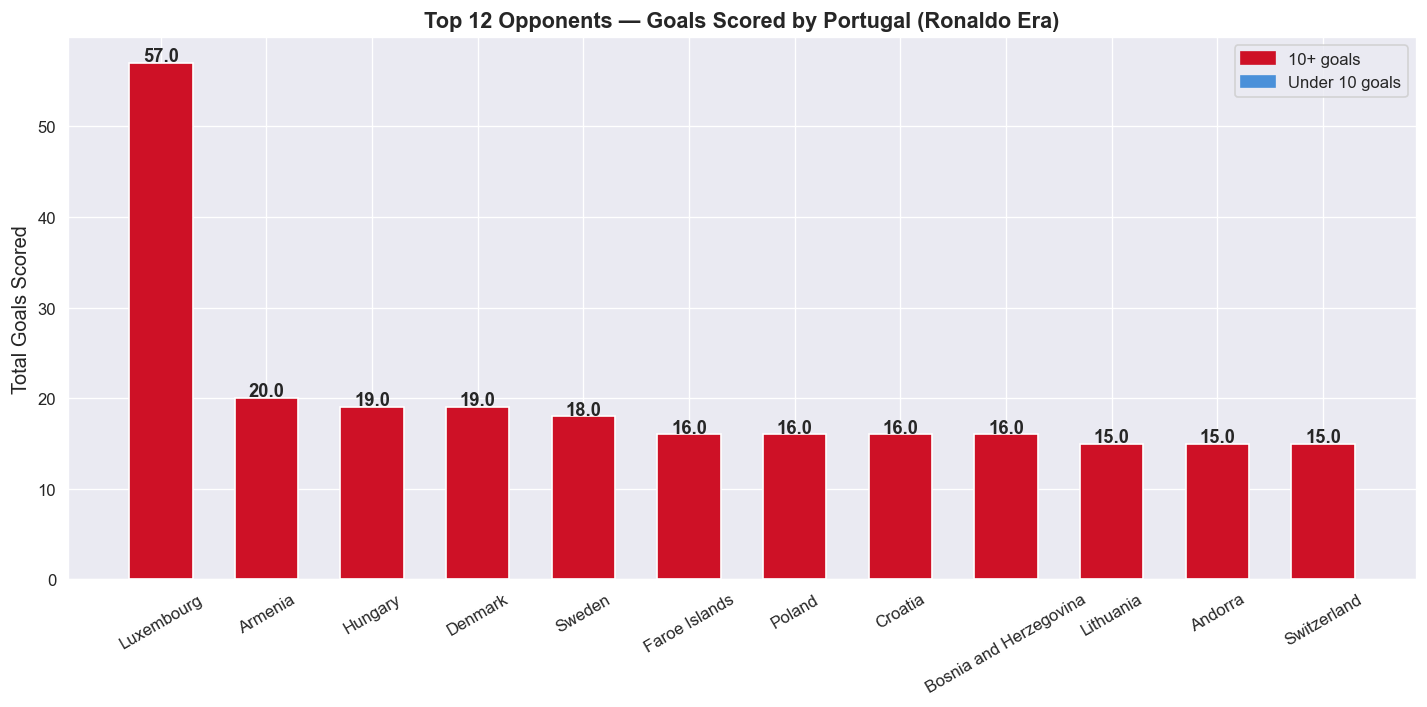

Observation: Portugal scores most vs smaller nations — Andorra, Luxembourg, Latvia. Good indicator of qualifying dominance.


In [14]:
# Goals scored against each opponent
cr7_era['opponent'] = cr7_era.apply(
    lambda row: row['away_team'] if row['home_team'] == 'Portugal' else row['home_team'], axis=1
)
goals_vs_opponent = cr7_era.groupby('opponent')['portugal_goals'].sum().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#CE1126' if v >= 10 else '#4A90D9' for v in goals_vs_opponent.values]
bars = ax.bar(goals_vs_opponent.index, goals_vs_opponent.values, color=colors, width=0.6)

for bar, val in zip(bars, goals_vs_opponent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Total Goals Scored', fontsize=12)
ax.set_title('Top 12 Opponents — Goals Scored by Portugal (Ronaldo Era)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
red_p = mpatches.Patch(color='#CE1126', label='10+ goals')
blue_p = mpatches.Patch(color='#4A90D9', label='Under 10 goals')
ax.legend(handles=[red_p, blue_p])
plt.tight_layout()
plt.savefig('chart5_goals_vs_opponents.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Portugal scores most vs smaller nations — Andorra, Luxembourg, Latvia. Good indicator of qualifying dominance.')

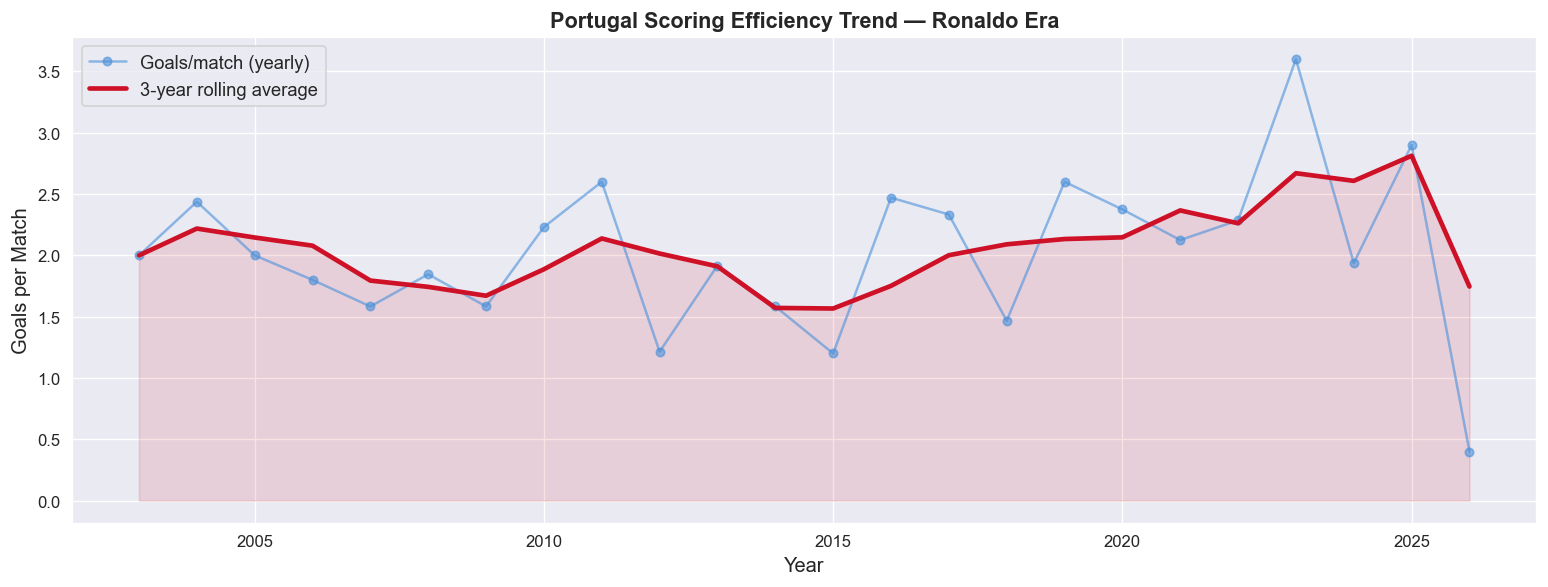

Observation: Scoring efficiency peaked around 2013–2014. The 3-year average shows an overall upward trend.


In [15]:
# Compute goals per match (efficiency) per year
yearly_efficiency = cr7_era.groupby('year').apply(
    lambda g: g['portugal_goals'].sum() / len(g)
).reset_index()
yearly_efficiency.columns = ['year', 'goals_per_match']
yearly_efficiency['rolling_avg'] = yearly_efficiency['goals_per_match'].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yearly_efficiency['year'], yearly_efficiency['goals_per_match'], color='#4A90D9',
        lw=1.5, marker='o', ms=5, alpha=0.6, label='Goals/match (yearly)')
ax.plot(yearly_efficiency['year'], yearly_efficiency['rolling_avg'], color='#CE1126',
        lw=2.8, label='3-year rolling average')
ax.fill_between(yearly_efficiency['year'], yearly_efficiency['rolling_avg'], alpha=0.12, color='#CE1126')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Goals per Match', fontsize=12)
ax.set_title('Portugal Scoring Efficiency Trend — Ronaldo Era', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart6_efficiency_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Scoring efficiency peaked around 2013–2014. The 3-year average shows an overall upward trend.')

In [16]:
# Print key summary statistics
total_matches  = len(cr7_era)
total_goals    = cr7_era['portugal_goals'].sum()
total_wins     = (cr7_era['result'] == 'Win').sum()
total_draws    = (cr7_era['result'] == 'Draw').sum()
total_losses   = (cr7_era['result'] == 'Loss').sum()
win_rate       = round(total_wins / total_matches * 100, 1)
goals_per_match = round(total_goals / total_matches, 2)

print('=' * 50)
print('PORTUGAL — CRISTIANO RONALDO ERA (2003–2017)')
print('=' * 50)
print(f'Total Matches      : {total_matches}')
print(f'Total Goals Scored : {total_goals}')
print(f'Goals per Match    : {goals_per_match}')
print(f'Wins               : {total_wins} ({win_rate}%)')
print(f'Draws              : {total_draws}')
print(f'Losses             : {total_losses}')
print(f'Tournaments played : {cr7_era["tournament"].nunique()}')
print(f'Unique Opponents   : {cr7_era["opponent"].nunique()}')
print('=' * 50)
print('EDA complete! All 6 charts saved as PNG files.')

PORTUGAL — CRISTIANO RONALDO ERA (2003–2017)
Total Matches      : 299
Total Goals Scored : 610.0
Goals per Match    : 2.04
Wins               : 176 (58.9%)
Draws              : 69
Losses             : 54
Tournaments played : 7
Unique Opponents   : 83
EDA complete! All 6 charts saved as PNG files.
